In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import yaml
import glob

import sys
import os
from pathlib import Path

# Notebookの場合は、現在の作業ディレクトリを起点にする
# 今いる場所がスクリプトを置いているディレクトリ（サブフォルダ）なら：
current_dir = Path.cwd()
parent_dir = str(current_dir.parent)

# もし絶対パスで指定してしまった方が確実なら、以下でもOKです
# parent_dir = "/home/user/project_name" 

if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
    print(f"Added to sys.path: {parent_dir}")

from Analysis import get_spike_indices

Added to sys.path: /home/satoshi/NeuMoReservoir


Loading data from: ../multirun/2026-04-10/12-38-55/8/data/buffer01.npz
Detected bAPs: 6
Detected dAPs: 28


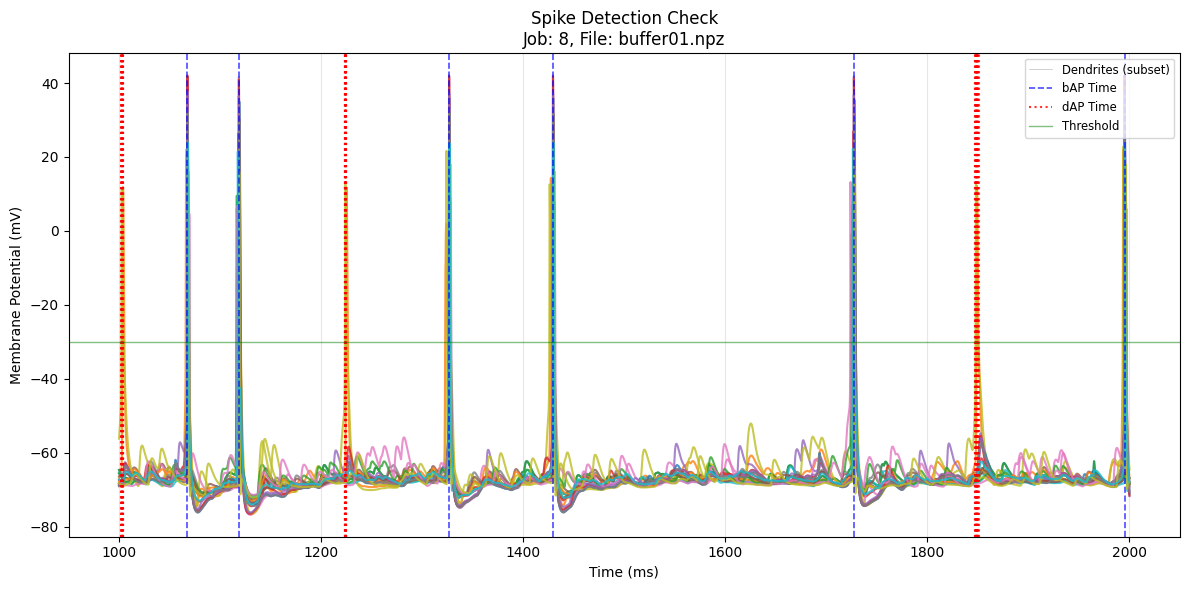

In [2]:
# --- 2. 可視化実行スクリプト ---
def visualize_spike_detection(base_path, job_index=0, file_index=0, num_compartments_to_plot=20):
    """
    指定されたデータの膜電位と検出されたスパイクをプロットする。
    """
    base_dir = Path(base_path)
    if not base_dir.exists():
        print(f"Error: Directory not found at {base_path}")
        return

    job_dirs = sorted([d for d in base_dir.iterdir() if d.is_dir() and d.name.isdigit()], 
                      key=lambda x: int(x.name))
    
    if not job_dirs or job_index >= len(job_dirs):
        print(f"Error: Job directory index {job_index} out of range.")
        return

    target_job_dir = job_dirs[job_index]
    buffer_files = sorted(glob.glob(str(target_job_dir / "data" / "buffer*.npz")))
    
    if not buffer_files or file_index >= len(buffer_files):
        print(f"Error: Buffer file index {file_index} out of range in {target_job_dir}")
        return

    # データのロード
    bf = buffer_files[file_index]
    print(f"Loading data from: {bf}")
    data_ts = np.load(bf, allow_pickle=True)
    t = data_ts['t_rec']
    vm = data_ts['variables'][1] # Vm (T, N_compartments)
    
    # --- スパイク抽出の実行 ---
    # 設定値（必要に応じて調整してください）
    V_THRESHOLD = -30
    SOMA_IDX = 0 # Somaがインデックス0であると仮定
    
    #bap_idx, dap_idx = get_spike_indices_refined(
    #    vm, t, 
    #    v_threshold=V_THRESHOLD, 
    #    soma_idx=SOMA_IDX,
    #    refractory_ms=2.0, 
    #    exclusion_window_ms=10.0
    #)
    
    bap_idx, dap_idx = get_spike_indices(
        vm, t,
        v_threshold=V_THRESHOLD
    )
    
    print(f"Detected bAPs: {len(bap_idx)}")
    print(f"Detected dAPs: {len(dap_idx)}")

    # --- プロットの作成 ---
    plt.figure(figsize=(12, 6))
    
    # 1. 膜電位の重ね描き
    num_total_comp = vm.shape[1]
    # プロットするコンパートメントを選択（間引き）
    step = max(1, num_total_comp // num_compartments_to_plot)
    comp_to_plot = range(0, num_total_comp, step)
    
    for i in comp_to_plot:
        plt.plot(t, vm[:, i], alpha=0.8, linewidth=1.5)

    # ダミープロット（凡例用）
    if num_total_comp > 1:
        plt.plot([], [], color='gray', alpha=0.5, linewidth=0.5, label='Dendrites (subset)')

    # 2. スパイクタイミングの可視化（縦の点線）
    # bAP (青色)
    is_first_bap = True
    for idx in bap_idx:
        label = 'bAP Time' if is_first_bap else ""
        plt.axvline(x=t[idx], color='blue', linestyle='--', alpha=0.7, linewidth=1.2, label=label)
        is_first_bap = False

    # dAP (赤色)
    is_first_dap = True
    for idx in dap_idx:
        label = 'dAP Time' if is_first_dap else ""
        plt.axvline(x=t[idx], color='red', linestyle=':', alpha=0.8, linewidth=1.5, label=label)
        is_first_dap = False

    # 3. グラフの設定
    plt.axhline(y=V_THRESHOLD, color='green', linestyle='-', alpha=0.5, linewidth=1, label='Threshold')
    plt.title(f"Spike Detection Check\nJob: {target_job_dir.name}, File: {Path(bf).name}")
    plt.xlabel("Time (ms)")
    plt.ylabel("Membrane Potential (mV)")
    plt.legend(loc='upper right', fontsize='small')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    
    plt.show()

# === 実行 ===
MULTIRUN_PATH = "../multirun/2026-04-10/12-38-55"

# 可視化を実行
visualize_spike_detection(MULTIRUN_PATH, job_index=8, file_index=1)